
# Tech Challenge - Fase 1 | Case NPS Preditivo

Este notebook foi estruturado para responder, de forma **separada e organizada**, às perguntas do desafio do PDF, combinando:

- entendimento do negócio;
- definição da variável target;
- análise exploratória com foco executivo;
- visualizações para storytelling com dados;
- proposta opcional de modelo preditivo.

**Arquivos utilizados**
- Base: `desafio_nps_fase_1.csv`
- Requisitos: `1IAST - Fase 1 - Tech Challenge (1).pdf`


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

BASE_DIR = Path('/data')
DATA_PATH = 'desafio_nps_fase_1.csv'


## 1. Carregamento da base e visão geral

In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
df.head()


Linhas: 2500 | Colunas: 19


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


In [3]:

info = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'n_unicos': df.nunique()
}).sort_index()
info


,tipo,nulos,n_unicos
complaints_count,int64,0,12
csat_internal_score,float64,0,98
customer_age,int64,0,52
customer_id,int64,0,2500
customer_region,str,0,5
customer_service_contacts,int64,0,8
customer_tenure_months,int64,0,119
delivery_attempts,int64,0,3
delivery_delay_days,int64,0,9
delivery_time_days,int64,0,13



### Leitura inicial do problema

A base reúne informações de cliente, pedido, logística, atendimento e satisfação. Isso permite investigar a pergunta central do case:

> **Quais fatores operacionais parecem influenciar a satisfação do cliente, medida pelo NPS?**


## 2. Respostas estruturadas às perguntas do PDF


### 2.1 Qual problema de negócio está sendo resolvido?

O problema é a **incapacidade de agir preventivamente** sobre a experiência do cliente. Hoje, o NPS é coletado apenas ao fim da jornada. Assim, a empresa descobre a insatisfação quando o dano já ocorreu.

Em termos práticos, o desafio busca responder:
- quais fatores operacionais mais afetam a experiência do cliente;
- o que transforma clientes em promotores, neutros ou detratores;
- como priorizar ações de logística e atendimento antes da pesquisa de NPS.

### 2.2 Por que o NPS é importante para um e-commerce?

O NPS é importante porque sintetiza a percepção do cliente sobre toda a experiência, incluindo pedido, entrega e suporte. Em e-commerce, ele se conecta diretamente a:
- recompra;
- reputação da marca;
- recomendação espontânea;
- retenção e market share.

### 2.3 Quais áreas se beneficiam desses insights?

- **Logística:** redução de atrasos e falhas de entrega.
- **Atendimento:** menor tempo de resolução e menos reincidência.
- **Produto/Operações:** melhoria da experiência ao longo da jornada.
- **Estratégia/CRM:** priorização de clientes em risco e campanhas preventivas.
- **Pricing/Comercial:** melhor leitura de percepção de valor versus experiência.

### 2.4 Como o NPS impacta recompra, boca a boca e market share?

- **Recompra:** clientes satisfeitos tendem a voltar a comprar.
- **Boca a boca:** promotores recomendam a marca; detratores espalham experiências negativas.
- **Market share:** melhor experiência fortalece retenção e aquisição indireta, aumentando competitividade.

### 2.5 Quais indicadores complementam a análise?

Além do NPS, vale acompanhar:
- CSAT;
- taxa de recompra;
- churn;
- SLA logístico;
- tempo médio de atendimento;
- taxa de reclamações;
- benchmark de NPS do setor.



## 3. Definição da target

### 3.1 Qual variável representa a satisfação do cliente?
A variável escolhida é **`nps_score`**, que vai de 0 a 10.

### 3.2 Por que ela foi escolhida?
Porque é a medida explícita de satisfação disponível na base e traduz a percepção final do cliente após sua jornada.

### 3.3 Em que momento ela é coletada?
Após a experiência de compra, incluindo entrega e eventuais interações com atendimento.

### 3.4 Existe risco em usar essa variável?
Sim. Os principais riscos são:
- o NPS é uma métrica **reativa**, não preventiva por natureza;
- ele mostra o resultado da experiência, mas não explica sozinho a causa;
- pode haver influência emocional do momento da resposta.


## 4. Preparação analítica e criação de faixas de NPS

In [4]:

def categorizar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    return 'Promotor'

analise = df.copy()
analise['nps_class'] = analise['nps_score'].apply(categorizar_nps)

analise['nps_class'].value_counts().to_frame('qtd')


,qtd
nps_class,
Detrator,1851
Neutro,448
Promotor,201


In [5]:

resumo = analise.describe(include='all').T
resumo[['count','mean','std','min','25%','50%','75%','max']].dropna(how='all')


,count,mean,std,min,25%,50%,75%,max
customer_id,"2,500.00","1,250.50",721.83,1.00,625.75,"1,250.50","1,875.25","2,500.00"
customer_age,"2,500.00",43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_region,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_tenure_months,"2,500.00",61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,"2,500.00","51,250.50",721.83,"50,001.00","50,625.75","51,250.50","51,875.25","52,500.00"
order_value,"2,500.00",434.26,289.77,7.76,220.25,375.51,577.29,"1,983.81"
items_quantity,"2,500.00",3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,"2,500.00",29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,"2,500.00",6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,"2,500.00",8.02,3.77,2.00,5.00,8.00,11.00,14.00


## 5. Análise exploratória com foco em negócio

### 5.1 Distribuição do NPS

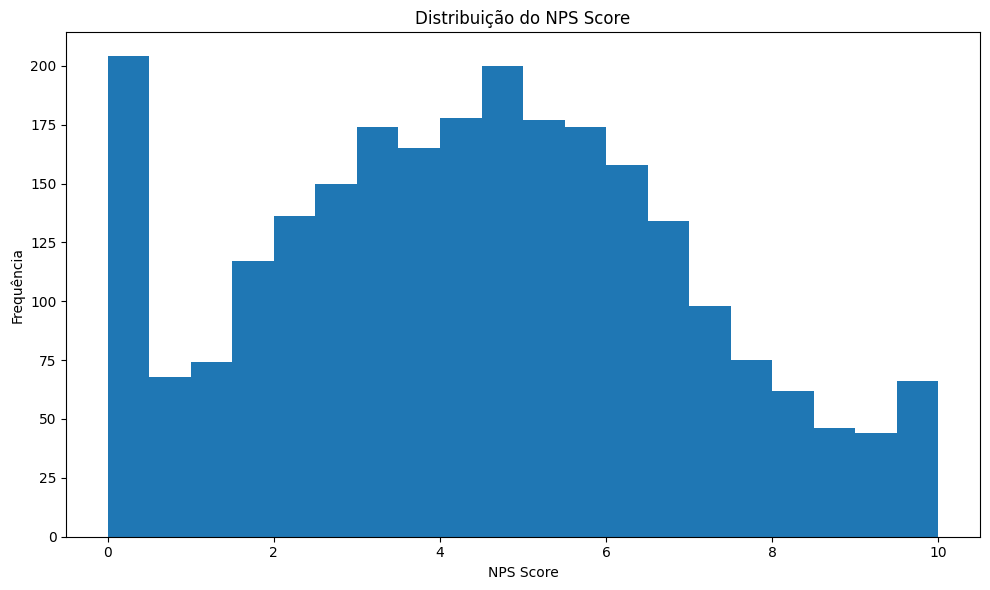

In [6]:

fig, ax = plt.subplots()
analise['nps_score'].plot(kind='hist', bins=20, ax=ax)
ax.set_title('Distribuição do NPS Score')
ax.set_xlabel('NPS Score')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / '01_distribuicao_nps.png', bbox_inches='tight')



**Leitura executiva:** a distribuição do NPS ajuda a identificar o equilíbrio entre clientes satisfeitos e insatisfeitos. Em contexto de negócio, interessa menos a forma estatística da curva e mais o volume concentrado em faixas críticas.


### 5.2 Distribuição por classe: detrator, neutro e promotor

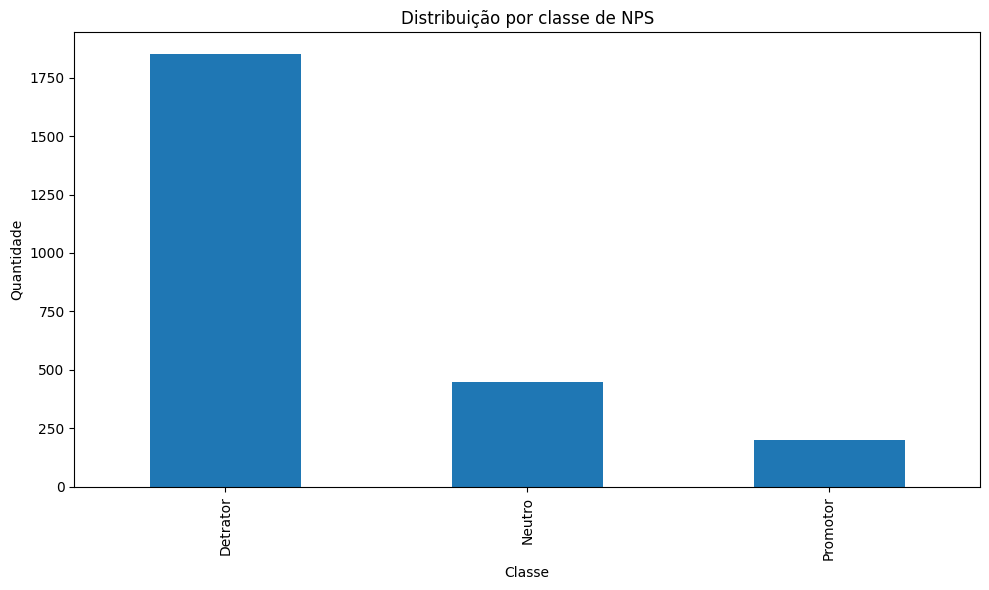

In [7]:

fig, ax = plt.subplots()
analise['nps_class'].value_counts().reindex(['Detrator','Neutro','Promotor']).plot(kind='bar', ax=ax)
ax.set_title('Distribuição por classe de NPS')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / '02_classes_nps.png', bbox_inches='tight')


### 5.3 Correlação entre variáveis numéricas e NPS

In [8]:

num_cols = analise.select_dtypes(include=['number']).columns.tolist()
corr = analise[num_cols].corr(numeric_only=True)
cor_nps = corr['nps_score'].sort_values()
cor_nps.to_frame('correlacao_com_nps')


,correlacao_com_nps
delivery_delay_days,-0.60
complaints_count,-0.50
customer_service_contacts,-0.35
resolution_time_days,-0.19
freight_value,-0.04
customer_age,-0.01
customer_tenure_months,-0.01
delivery_time_days,0.00
items_quantity,0.01
customer_id,0.02


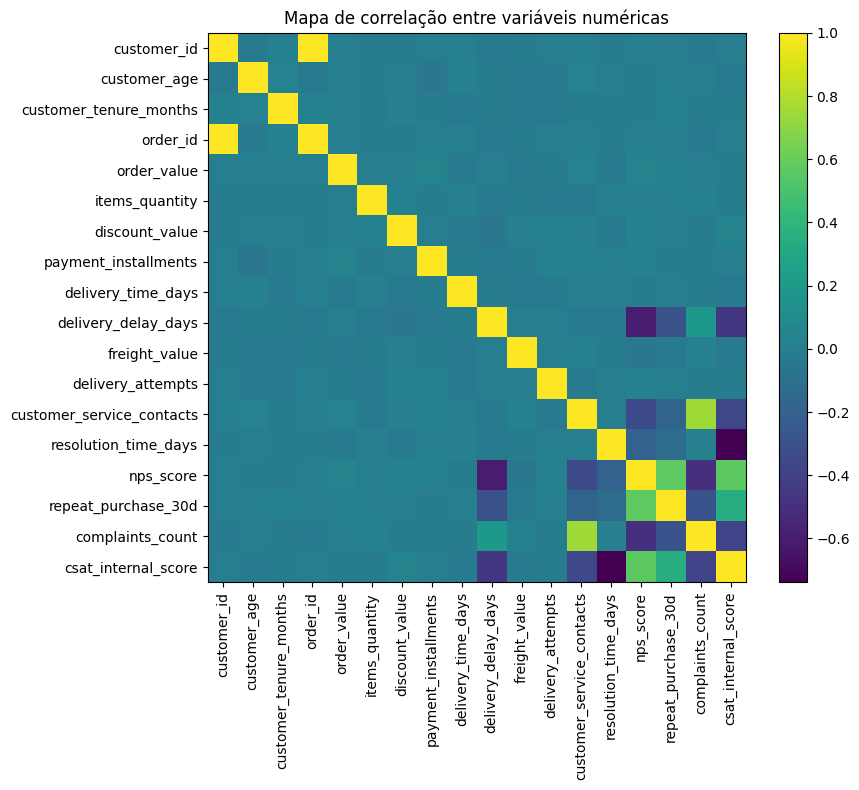

In [9]:

fig, ax = plt.subplots(figsize=(9,8))
mat = ax.imshow(corr, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
ax.set_title('Mapa de correlação entre variáveis numéricas')
fig.colorbar(mat)
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / '03_heatmap_correlacao.png', bbox_inches='tight')



**Leitura executiva dos drivers:**
- Correlações negativas relevantes com NPS costumam indicar pontos de dor operacional.
- Correlações positivas sugerem variáveis associadas a boa experiência.
- Em um e-commerce, espera-se destaque para atraso, reclamações, contatos com suporte e score interno de satisfação.


### 5.4 Quais fatores parecem mais críticos para a satisfação?

In [10]:
criticos = cor_nps.drop('nps_score').sort_values()
mais_negativos = criticos.head(5)
mais_positivos = criticos.tail(5).sort_values(ascending=False)

print('Top 5 impactos negativos:')
print(mais_negativos.to_frame('correlacao'))
print('\nTop 5 impactos positivos:')
print(mais_positivos.to_frame('correlacao'))


Top 5 impactos negativos:
                           correlacao
delivery_delay_days             -0.60
complaints_count                -0.50
customer_service_contacts       -0.35
resolution_time_days            -0.19
freight_value                   -0.04

Top 5 impactos positivos:
                     correlacao
repeat_purchase_30d        0.57
csat_internal_score        0.56
order_value                0.04
delivery_attempts          0.03
discount_value             0.03



**Resposta:** os fatores mais críticos tendem a estar ligados a **atraso logístico**, **reclamações**, **contatos com atendimento** e **tempo de resolução**. Do lado positivo, recompra e score interno de satisfação costumam acompanhar notas maiores de NPS.


### 5.5 O que mais gera detratores?

In [11]:

agrupado_classes = analise.groupby('nps_class')[[
    'delivery_delay_days',
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',
    'csat_internal_score',
    'repeat_purchase_30d'
]].mean().reindex(['Detrator','Neutro','Promotor'])
agrupado_classes


,delivery_delay_days,customer_service_contacts,resolution_time_days,complaints_count,csat_internal_score,repeat_purchase_30d
nps_class,,,,,,
Detrator,2.53,1.69,5.79,4.62,2.34,0.00
Neutro,1.40,1.13,4.83,2.99,4.23,0.04
Promotor,0.76,0.78,4.10,2.39,5.60,1.00


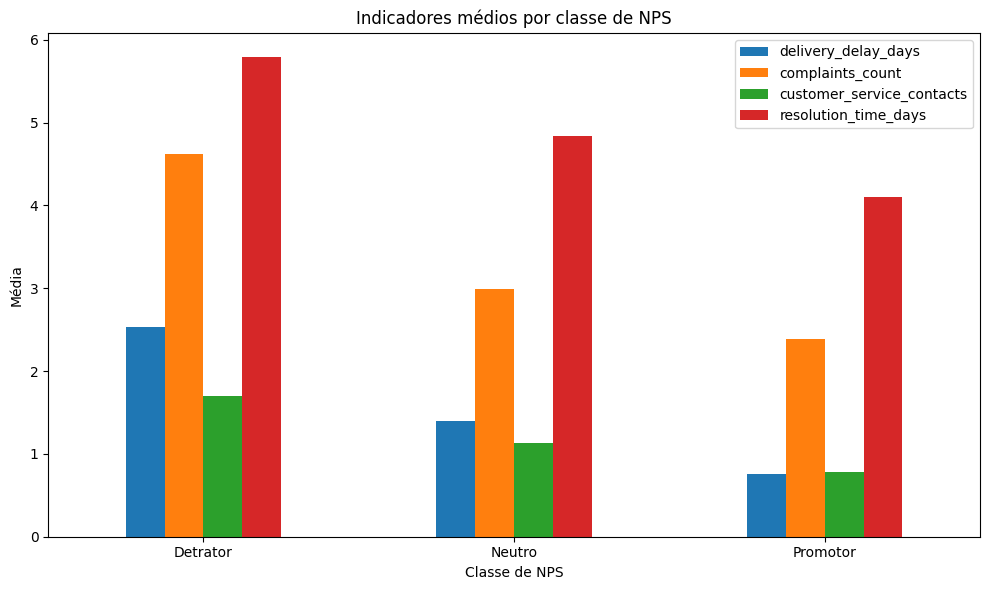

In [12]:

fig, ax = plt.subplots()
agrupado_classes[['delivery_delay_days','complaints_count','customer_service_contacts','resolution_time_days']].plot(kind='bar', ax=ax)
ax.set_title('Indicadores médios por classe de NPS')
ax.set_xlabel('Classe de NPS')
ax.set_ylabel('Média')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / '04_indicadores_por_classe.png', bbox_inches='tight')



**Resposta:** detratores costumam apresentar, em média, maior atraso, mais reclamações, mais interações com atendimento e maior tempo de resolução. Isso sugere que a insatisfação não nasce de um único evento, mas de uma **jornada com fricção acumulada**.


### 5.6 Existe ponto de ruptura na experiência?

In [13]:

delay_bins = pd.cut(analise['delivery_delay_days'], bins=[-1,0,2,5,10,100], labels=['0','1-2','3-5','6-10','11+'])
delay_view = analise.groupby(delay_bins)['nps_score'].agg(['mean','count'])
delay_view


,mean,count
delivery_delay_days,,
0,6.86,277
1-2,5.05,1261
3-5,2.89,911
6-10,0.81,51


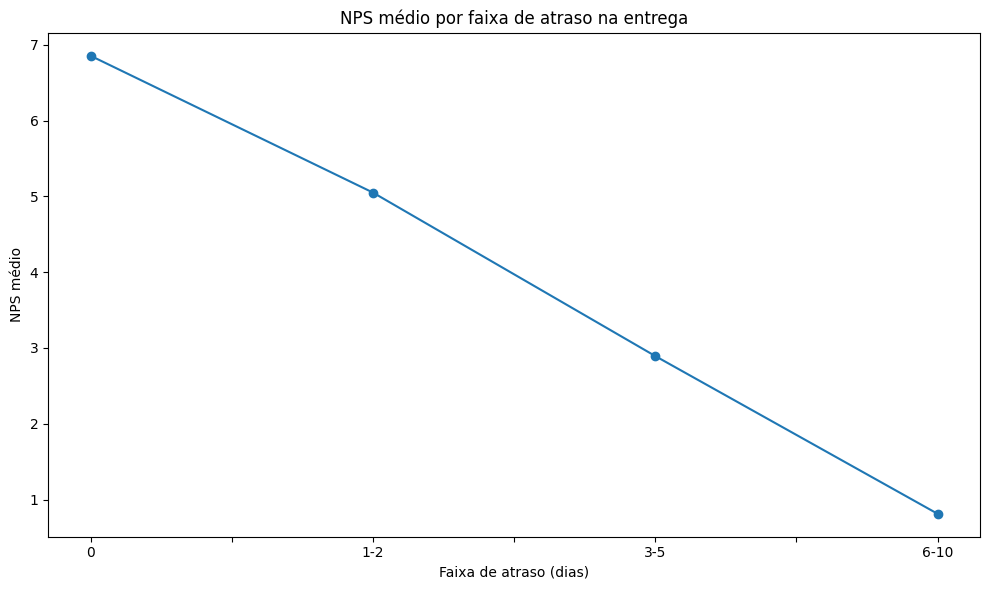

In [14]:

fig, ax = plt.subplots()
delay_view['mean'].plot(marker='o', ax=ax)
ax.set_title('NPS médio por faixa de atraso na entrega')
ax.set_xlabel('Faixa de atraso (dias)')
ax.set_ylabel('NPS médio')
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / '05_nps_por_faixa_atraso.png', bbox_inches='tight')



**Resposta:** o atraso de entrega funciona como um provável **ponto de ruptura**. Quando ele cresce, o NPS médio tende a cair de forma clara. Para negócio, isso indica que evitar atraso é mais estratégico do que apenas remediar depois.


### 5.7 Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

In [15]:

regiao = analise.groupby('customer_region')['nps_score'].mean().sort_values()
tenure_faixa = pd.cut(analise['customer_tenure_months'], bins=[0,6,12,24,60,120], labels=['0-6','7-12','13-24','25-60','61-120'])
tenure_view = analise.groupby(tenure_faixa)['nps_score'].mean()

print('NPS médio por região:')
print(regiao.to_frame('nps_medio'))
print('\nNPS médio por faixa de relacionamento:')
print(tenure_view.to_frame('nps_medio'))


NPS médio por região:
                 nps_medio
customer_region           
Centro-Oeste          4.21
Sudeste               4.37
Norte                 4.38
Nordeste              4.42
Sul                   4.49

NPS médio por faixa de relacionamento:
                        nps_medio
customer_tenure_months           
0-6                          4.17
7-12                         4.12
13-24                        4.65
25-60                        4.35
61-120                       4.39


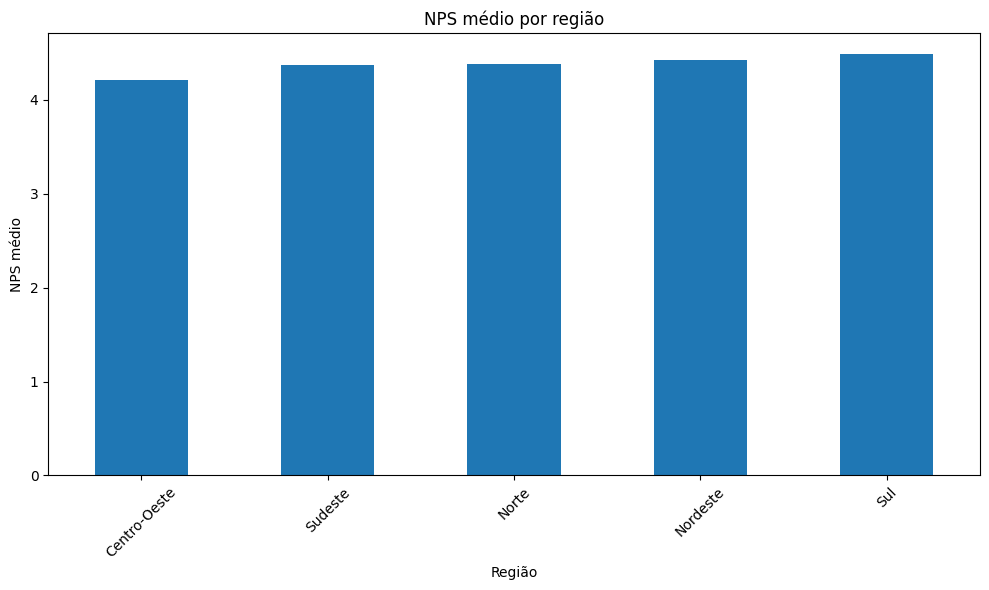

In [16]:

fig, ax = plt.subplots()
regiao.plot(kind='bar', ax=ax)
ax.set_title('NPS médio por região')
ax.set_xlabel('Região')
ax.set_ylabel('NPS médio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / '06_nps_por_regiao.png', bbox_inches='tight')



**Resposta:** clientes com NPS mais alto tendem a vivenciar entregas sem atraso, baixo contato com suporte e poucas reclamações. Já clientes com NPS baixo concentram falhas operacionais e necessidade de resolução posterior.


## 6. Conclusões executivas da EDA


### Principais insights

1. **Atraso logístico é um dos principais drivers de insatisfação.**
2. **Reclamações e múltiplos contatos com atendimento ampliam o risco de detratores.**
3. **Tempo de resolução também pesa negativamente na experiência.**
4. **Clientes com sinais de recompra e bom CSAT interno tendem a apresentar NPS mais alto.**
5. **A jornada precisa ser vista de ponta a ponta:** logística ruim e atendimento reativo formam uma combinação crítica.


## 7. Recomendações práticas para o negócio


### Recomendações

- **Priorizar a redução de atrasos** e monitorar pedidos em risco em tempo real.
- **Atuar sobre reincidência de contatos**, buscando resolver no primeiro atendimento.
- **Criar alertas operacionais** para clientes com combinação de atraso + reclamação + alta resolução.
- **Usar o NPS de forma preventiva**, via modelos preditivos e regras de negócio.
- **Integrar logística, atendimento e CRM** para ações antes da aplicação da pesquisa.


## 8. Modelo preditivo opcional


A proposta mais útil para o negócio é uma **classificação** do cliente em **Detrator, Neutro ou Promotor**, permitindo priorizar ações.


In [17]:

features = [c for c in analise.columns if c not in ['nps_score','nps_class','customer_id','order_id']]
X = analise[features]
y = analise['nps_class']

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

model = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

    Detrator       0.84      0.98      0.90       555
      Neutro       0.70      0.21      0.32       135
    Promotor       0.94      1.00      0.97        60

    accuracy                           0.84       750
   macro avg       0.83      0.73      0.73       750
weighted avg       0.82      0.84      0.80       750



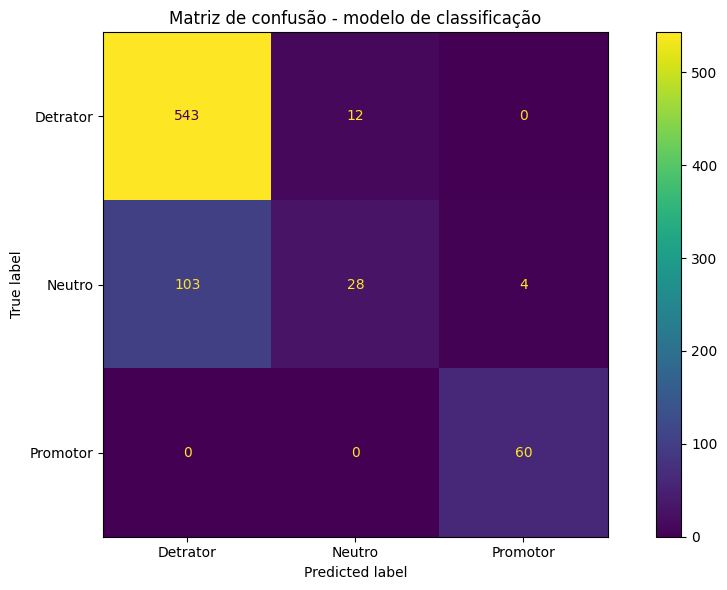

In [18]:

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax)
ax.set_title('Matriz de confusão - modelo de classificação')
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / '07_matriz_confusao.png', bbox_inches='tight')



### Como essa solução pode ser usada na prática?

- identificar pedidos com risco de gerar detratores;
- acionar logística e atendimento antes do encerramento da jornada;
- priorizar clientes críticos em campanhas de recuperação;
- transformar dados operacionais em uma esteira de prevenção da insatisfação.


## 9. Limitações e riscos da estratégia


- Correlação não implica causalidade.
- O NPS é coletado após a experiência, então há limitação temporal.
- A base não traz texto livre ou motivação qualitativa das reclamações.
- Um modelo treinado nessa base precisaria de validação contínua em produção.


## 10. Encerramento


Este notebook foi construído para atender ao desafio com foco em **negócio + análise + comunicação executiva**. Ele pode ser usado como base para:
- o repositório no GitHub;
- a apresentação em slides;
- o roteiro do vídeo executivo.
